# Configs

In [1]:
# 1. Instalação com Upgrade e correção de conflito do pyarrow
!pip install -q -U pyarrow transformers datasets accelerate evaluate

import os
import pandas as pd
import numpy as np
import torch
import random
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import evaluate

# --- REPRODUTIBILIDADE  ---
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

# Configurações de determinismo para o PyTorch
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Definir dispositivo (GPU ou CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Ambiente configurado. Dispositivo: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
✅ Ambiente configurado. Dispositivo: cuda


# Pre-process

In [17]:
import pandas as pd
import re

def clean_content(text):
    """
    Limpeza fundamental para evitar Data Leakage.
    Remove apenas a marca da Reuters e URLs, mantendo Maiúsculas e Pontuação.
    """
    text = str(text)
    # 1. Remover Menção à Reuters (Leakage estatístico de 99.9%)
    text = re.sub(r'^.*?\(Reuters\)\s*[-—]\s*', '', text, flags=re.IGNORECASE)

    # 2. Remover URLs (Não agregam valor semântico)
    text = re.sub(r'http\S+', '', text)

    # 3. Normalizar espaços e quebras de linha
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

def prepare_train_data(path):
    """
    Processa o treino: remove duplicatas e prepara Título e Texto como colunas distintas.
    """
    # Carregamento robusto para evitar erros de aspas
    df = pd.read_csv(path, engine='python', on_bad_lines='skip')

    # A. Remover Duplicatas (Essencial para integridade científica)
    df = df.drop_duplicates(subset=['title', 'text'])

    # B. Validar Labels
    df = df[df['label'].astype(str).isin(['0', '1', '0.0', '1.0'])]
    df['label'] = df['label'].astype(int)

    # C. Limpeza de Conteúdo (Mantendo Upper Case)
    # Título e Texto permanecem em colunas separadas para o Tokenizer
    df['title_clean'] = df['title'].apply(lambda x: re.sub(r'\s+', ' ', str(x)).strip())
    df['text_clean'] = df['text'].apply(clean_content)

    # D. Filtro de Ruído: Garante que haja conteúdo mínimo para o modelo ler
    df = df[(df['title_clean'].str.len() > 5) & (df['text_clean'].str.len() > 20)]

    print(f"✅ Treino preparado: {df.shape[0]} amostras após limpeza.")
    return df[['id', 'title_clean', 'text_clean', 'label']]

def prepare_test_data(path):
    """
    Processa o teste: mantém a quantidade original de linhas e limpa o texto.
    """
    df = pd.read_csv(path, engine='python', on_bad_lines='skip')

    # A. Limpeza de Conteúdo (Idêntica ao treino para consistência)
    df['title_clean'] = df['title'].apply(lambda x: re.sub(r'\s+', ' ', str(x)).strip())
    df['text_clean'] = df['text'].apply(clean_content)

    # No teste, não removemos linhas, apenas garantimos que não há strings vazias
    # Se o texto estiver vazio após a limpeza, o Título ainda servirá de base

    print(f"✅ Teste preparado: {df.shape[0]} amostras.")
    return df[['id', 'title_clean', 'text_clean']]

# Prepare and tokenized

In [18]:
def prepare_tokenized_datasets(model_name, df_train, df_test):
    """
    Recebe o nome do modelo e os dataframes limpos.
    Retorna os datasets tokenizados prontos para o modelo.
    """
    print(f"📥 Carregando Tokenizer: {model_name}...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 1. Converter para formato Dataset
    ds_train = Dataset.from_pandas(df_train)
    ds_test = Dataset.from_pandas(df_test)

    # 2. Função interna de tokenização
    def tokenize_function(batch):
        return tokenizer(
            batch["title_clean"],
            batch["text_clean"],
            padding="max_length",
            truncation=True,
            max_length=256
        )

    # 3. Mapear tokenização
    print("✂️ Tokenizando datasets...")
    tok_train = ds_train.map(tokenize_function, batched=True, desc="Treino")
    tok_test = ds_test.map(tokenize_function, batched=True, desc="Teste")

    # 4. Limpeza de colunas DINÂMICA
    # Lista de colunas que queremos remover se existirem
    cols_to_remove_base = ['title_clean', 'text_clean', '__index_level_0__']

    #remover apenas as que de fato estão no dataset
    actual_cols_train = [c for c in cols_to_remove_base + ['id'] if c in tok_train.column_names]
    actual_cols_test = [c for c in cols_to_remove_base if c in tok_test.column_names]

    tok_train = tok_train.remove_columns(actual_cols_train)
    tok_test = tok_test.remove_columns(actual_cols_test)

    print(f"✅ Tokenização concluída para {model_name}")
    print(f"Colunas finais no treino: {tok_train.column_names}")

    return tok_train, tok_test, tokenizer

# Training

In [19]:
# --- FUNÇÃO DE TREINAMENTO ---

def train_model(model_name, tokenized_dataset, tokenizer_obj, epochs=5):
    """
    Realiza o fine-tuning de um modelo específico.
    Retorna o trainer treinado e as métricas de validação.
    """
    print(f"\n⚙️ Configurando treinamento para: {model_name}")

    # 1. Divisão interna para Validação (15%)
    # Usamos o dataset tokenizado que veio da função anterior
    split_ds = tokenized_dataset.train_test_split(test_size=0.15, seed=42)
    train_subset = split_ds["train"]
    eval_subset = split_ds["test"]

    # 2. Carregar o Modelo
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device)

    # 3. Métrica F1
    f1_metric = evaluate.load("f1")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        return f1_metric.compute(predictions=predictions, references=labels)

    # 4. Configurar Hiperparâmetros
    training_args = TrainingArguments(
        output_dir=f"./results_{model_name.split('/')[-1]}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        num_train_epochs=epochs,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=torch.cuda.is_available(),
        seed=42,
        data_seed=42,
        report_to="none"
    )

    # 5. Inicializar o Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_subset,
        eval_dataset=eval_subset,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer_obj),
        compute_metrics=compute_metrics,
    )

    # 6. Treinar
    print(f"🚀 Iniciando treino de {model_name}...")
    trainer.train()

    # Avaliação final para retornar métricas limpas
    metrics = trainer.evaluate()
    print(f"✅ Treino concluído! F1-Score Final: {metrics['eval_f1']:.4f}")

    return trainer, metrics

# Submition

In [5]:
# --- FUNÇÃO DE PREDIÇÃO E GERAÇÃO DE SUBMISSÃO ---

def generate_submission(trainer_obj, tokenized_test_ds, original_test_df, model_name):
    """
    Usa um trainer treinado para prever o conjunto de teste e gera o CSV de submissão.
    """
    print(f"🔍 Iniciando predições com o modelo: {model_name}...")

    # 1. Gerar predições
    # O trainer utiliza o melhor checkpoint salvo (load_best_model_at_end)
    test_predictions = trainer_obj.predict(tokenized_test_ds)

    # 2. Converter logits para classes (0 ou 1)
    predictions = np.argmax(test_predictions.predictions, axis=-1)

    # 3. Criar o DataFrame de submissão
    # Garantimos o uso do 'id' original para integridade do desafio
    submission_df = pd.DataFrame({
        'id': original_test_df['id'],
        'label': predictions
    })

    # 4. Salvar o arquivo CSV
    # Nomeamos o arquivo com base no modelo para evitar confusão
    filename = f'submission_{model_name.split("/")[-1]}.csv'
    submission_df.to_csv(filename, index=False)

    print(f"\n✅ Ficheiro '{filename}' gerado com sucesso!")
    print(f"📊 Total de linhas: {len(submission_df)}")
    print(f"📈 Distribuição das classes:\n{submission_df['label'].value_counts()}")

    # Tentativa de download automático no Colab
    try:
        from google.colab import files
        files.download(filename)
    except Exception as e:
        print(f"\n[Nota] Download automático falhou. Podes baixar '{filename}' na aba de arquivos.")

    return submission_df

# Full pipeline

In [ ]:
# --- CÉLULA: PIPELINE DE EXPERIMENTAÇÃO COMPLETO ---

def run_full_experiment(model_name, df_train, df_test, epochs=5):
    """
    Executa o fluxo fim-a-fim: Tokenização -> Treino -> Submissão.
    """
    print(f"\n{'='*60}")
    print(f"🏁 INICIANDO EXPERIMENTO: {model_name}")
    print(f"{'='*60}")

    # 1. Fase de Tokenização
    # (Usa a função que criamos na Célula 3)
    tok_train, tok_test, tokenizer_obj = prepare_tokenized_datasets(
        model_name, df_train, df_test
    )

    # 2. Fase de Treinamento
    # (Usa a função que criamos na Célula 4)
    trainer_obj, metrics = train_model(
        model_name, tok_train, tokenizer_obj, epochs=epochs
    )

    # 3. Fase de Submissão
    # (Usa a função que criamos na Célula 5)
    submission_df = generate_submission(
        trainer_obj, tok_test, df_test, model_name
    )

    print(f"\n✨ Experimento com {model_name} finalizado com sucesso!")
    return {
        'model': model_name,
        'f1': metrics['eval_f1'],
        'trainer': trainer_obj
    }

# Execution

In [20]:
# --- EXECUÇÃO DO PREPROCESSAMENTO ---

train_final = prepare_train_data('train.csv')
test_final = prepare_test_data('test.csv')

# Exemplo de como os dados serão alimentados no modelo
print("\n--- Estrutura Final para o Tokenizer ---")
print(f"Colunas do Treino: {train_final.columns.tolist()}")
print(f"Exemplo Título: {train_final['title_clean'].iloc[0]}")
print(f"Exemplo Texto: {train_final['text_clean'].iloc[0][:150]}...")

✅ Treino preparado: 22169 amostras após limpeza.
✅ Teste preparado: 5712 amostras.

--- Estrutura Final para o Tokenizer ---
Colunas do Treino: ['id', 'title_clean', 'text_clean', 'label']
Exemplo Título: Exclusive: Pentagon, Lockheed near deal on $9 billion F-35 contract - sources
Exemplo Texto: The U.S. Department of Defense and Lockheed Martin Corp (LMT.N) are close to deal for a contract worth almost $9 billion as negotiations are poised to...


In [21]:

# --- BLOCO DE EXECUÇÃO FINAL ---

# O usuário só precisa alterar esta lista para testar quantos modelos quiser
modelos_para_testar = ["distilroberta-base", "distilbert-base-uncased"]

# Dicionário para guardar os resultados de cada modelo para comparação posterior
historico_experimentos = []

for checkpoint in modelos_para_testar:
    resultado = run_full_experiment(checkpoint, train_final, test_final)
    historico_experimentos.append(resultado)

    # Limpeza de memória para o próximo modelo (importante na T4!)
    torch.cuda.empty_cache()
    import gc
    gc.collect()


🏁 INICIANDO EXPERIMENTO: distilroberta-base
📥 Carregando Tokenizer: distilroberta-base...
✂️ Tokenizando datasets...


Treino:   0%|          | 0/22169 [00:00<?, ? examples/s]

Teste:   0%|          | 0/5712 [00:00<?, ? examples/s]

✅ Tokenização concluída para distilroberta-base
Colunas finais no treino: ['label', 'input_ids', 'attention_mask']

⚙️ Configurando treinamento para: distilroberta-base


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


✅ Treino concluído! F1-Score Final: 0.9974
🔍 Iniciando predições com o modelo: distilbert-base-uncased...

✅ Ficheiro 'submission_distilbert-base-uncased.csv' gerado com sucesso!
📊 Total de linhas: 5712
📈 Distribuição das classes:
label
0    4283
1    1429
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✨ Experimento com distilbert-base-uncased finalizado com sucesso!


# Evaluate model performance (F1, Recall, Confusion Matrix, ROC-AUC)

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, recall_score, confusion_matrix, classification_report

def evaluate_model_performance(trainer, tokenized_test, df_test, model_name):
    """
    Realiza a predição no conjunto de teste e plota Matriz de Confusão, F1 e Recall.
    """
    print(f"📊 Avaliando performance para: {model_name}...")

    # 1. Obter predições do Trainer
    predictions = trainer.predict(tokenized_test)
    y_true = predictions.label_ids
    # Pegamos o argmax para transformar as probabilidades em classes (0 ou 1)
    y_pred = np.argmax(predictions.predictions, axis=-1)

    # 2. Calcular Métricas
    f1 = f1_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)

    print(f"\n✅ Resultados Finais - {model_name}")
    print(f"{'-'*30}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Recall:   {recall:.4f}")
    print(f"\nRelatório de Classificação:\n")
    print(classification_report(y_true, y_pred, target_names=['Real (0)', 'Fake (1)']))

    # 3. Plotar Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Previsto Real', 'Previsto Fake'],
                yticklabels=['Fato Real', 'Fato Fake'])

    plt.title(f'Matriz de Confusão - {model_name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Predito')
    plt.show()

    return {"f1": f1, "recall": recall, "cm": cm}

📊 Avaliando performance para: DistilRoBERTa...



✅ Resultados Finais - DistilRoBERTa
------------------------------
F1-Score: 1.0000
Recall:   1.0000

Relatório de Classificação:

              precision    recall  f1-score   support

    Real (0)       1.00      1.00      1.00      2557
    Fake (1)       1.00      1.00      1.00       769

    accuracy                           1.00      3326
   macro avg       1.00      1.00      1.00      3326
weighted avg       1.00      1.00      1.00      3326



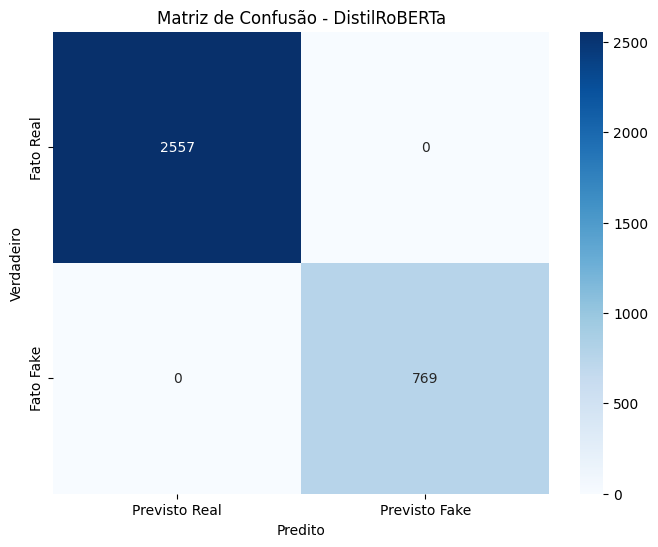

In [49]:
dataset_teste_pronto = historico_experimentos[0]['trainer'].eval_dataset
resultados_roberta = evaluate_model_performance(
    historico_experimentos[0]['trainer'],
    dataset_teste_pronto,
    test_final,
    "DistilRoBERTa"
)



📊 Avaliando performance para: DistilBERT...



✅ Resultados Finais - DistilBERT
------------------------------
F1-Score: 0.9974
Recall:   0.9961

Relatório de Classificação:

              precision    recall  f1-score   support

    Real (0)       1.00      1.00      1.00      2557
    Fake (1)       1.00      1.00      1.00       769

    accuracy                           1.00      3326
   macro avg       1.00      1.00      1.00      3326
weighted avg       1.00      1.00      1.00      3326



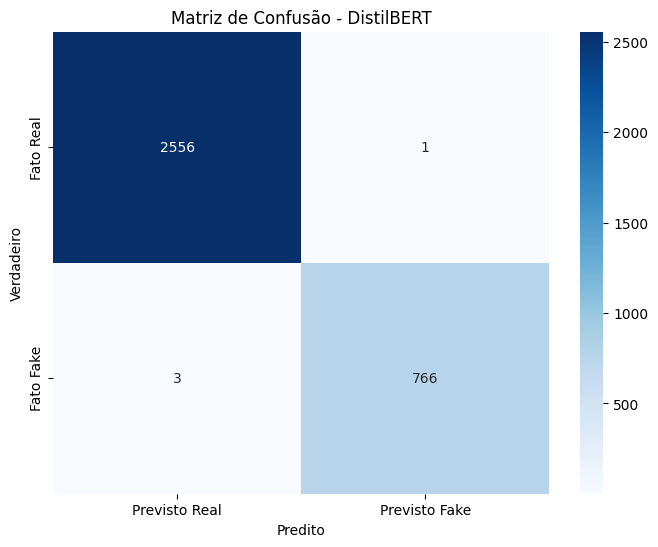

In [50]:

trainer_bert = historico_experimentos[1]['trainer']
dataset_teste_bert = trainer_bert.eval_dataset

resultados_bert = evaluate_model_performance(
    trainer_bert,
    dataset_teste_bert,
    test_final,
    "DistilBERT"
)

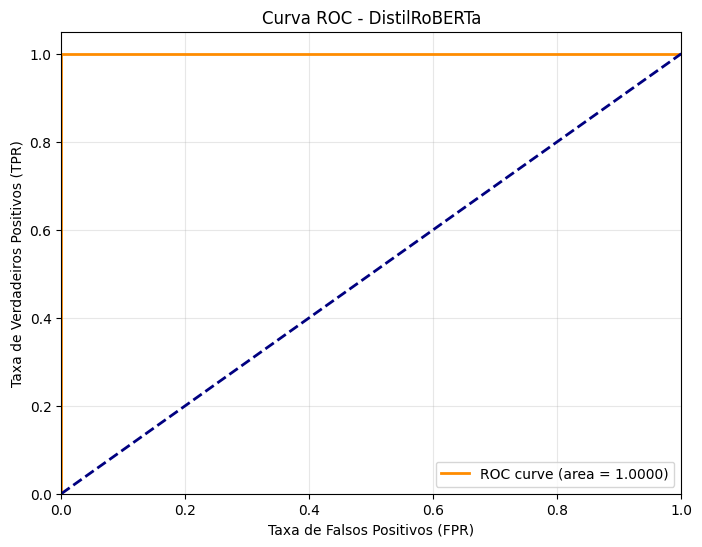

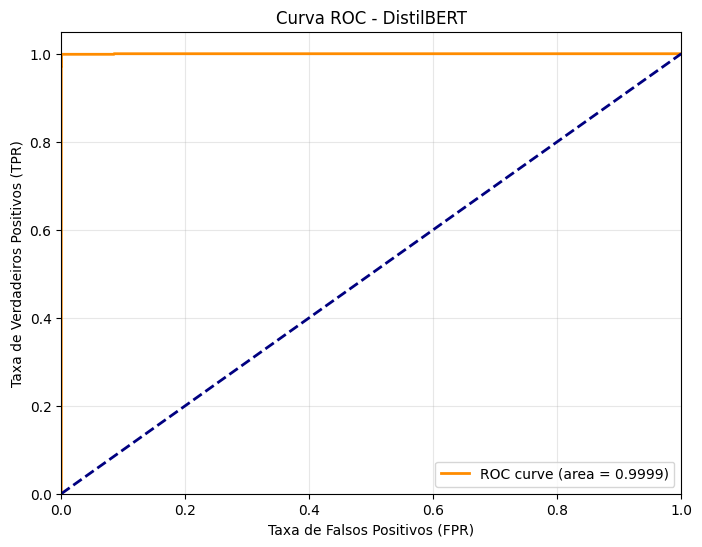

In [52]:
from sklearn.metrics import roc_curve, auc

def plot_roc_curve(trainer, tokenized_test, model_name):
    """
    Calcula e plota a Curva ROC e o valor AUC para modelos Transformer.
    """
    predictions = trainer.predict(tokenized_test)
    y_true = predictions.label_ids

    probs = torch.nn.functional.softmax(torch.from_numpy(predictions.predictions), dim=-1)
    y_score = probs[:, 1].numpy()

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Taxa de Falsos Positivos (FPR)')
    plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
    plt.title(f'Curva ROC - {model_name}')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return roc_auc

auc_roberta = plot_roc_curve(historico_experimentos[0]['trainer'], historico_experimentos[0]['trainer'].eval_dataset, "DistilRoBERTa")
auc_bert = plot_roc_curve(historico_experimentos[1]['trainer'], historico_experimentos[1]['trainer'].eval_dataset, "DistilBERT")

# SHAP

In [23]:
# 1. Extraindo o DistilRoBERTa
exp_roberta = historico_experimentos[0]
model_roberta = exp_roberta['trainer'].model

# 2. Extraindo o DistilBERT
exp_bert = historico_experimentos[1]
model_bert = exp_bert['trainer'].model

# 3. Colocando ambos em modo de avaliação (importante para o SHAP e inferência)
model_roberta.eval()
model_bert.eval()

print("✅ Modelos e Tokenizers extraídos com sucesso!")
print(f"Modelo 1: {exp_roberta['model']} | F1: {exp_roberta['f1']:.4f}")
print(f"Modelo 2: {exp_bert['model']} | F1: {exp_bert['f1']:.4f}")

✅ Modelos e Tokenizers extraídos com sucesso!
Modelo 1: distilroberta-base | F1: 1.0000
Modelo 2: distilbert-base-uncased | F1: 0.9974


In [26]:
import shap
import torch
import numpy as np

def run_shap_interpretation(model, model_name, text, device="cuda"):
    """
    Função replicável para interpretar predições de modelos Transformer usando SHAP.

    Parâmetros:
    - model: O modelo treinado (ex: model_roberta ou model_bert)
    - tokenizer: O tokenizer correspondente ao modelo
    - text: String contendo o texto da notícia (Título + Texto)
    - device: "cuda" para GPU ou "cpu"
    """

    # 1. Garantir que o modelo esteja no modo de avaliação e no dispositivo correto
    model.to(device)
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # 2. Definir a função de predição interna que o SHAP utilizará
    def predict_function(texts):
        # O SHAP passa as perturbações como um array de strings
        inputs = tokenizer(
            texts.tolist(),
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=256
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            # Retornamos as probabilidades (Softmax) para ambas as classes
            return torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()

    # 3. Inicializar o Explainer de Texto do SHAP
    # O Explainer de texto é mais eficiente para modelos do Hugging Face
    explainer = shap.Explainer(predict_function, tokenizer)

    # 4. Calcular os valores SHAP para o texto fornecido
    print(f"⌛ Calculando valores SHAP (isso pode levar alguns instantes)...")
    shap_values = explainer([text])

    # 5. Gerar a visualização interativa
    # Nota: No Jupyter/Colab, isso renderiza o gráfico de barras coloridas no texto
    shap.plots.text(shap_values[0])

    return shap_values


In [43]:
# Exemplo 1: Testando com o DistilRoBERTa em uma Notícia Real (ID 424):
idx_escolhido = 424
noticia_teste = test_final.loc[idx_escolhido, 'title_clean'] + " " + test_final.loc[idx_escolhido, 'text_clean']
run_shap_interpretation(model_roberta, "distilroberta-base", noticia_teste)

⌛ Calculando valores SHAP (isso pode levar alguns instantes)...


.values =
array([[[ 1.49235951e-03, -1.49235916e-03],
        [ 1.93126791e-02, -1.93126802e-02],
        [ 1.09665394e-02, -1.09665394e-02],
        [ 1.10935897e-02, -1.10935890e-02],
        [ 1.68903241e-02, -1.68903258e-02],
        [ 1.62522248e-02, -1.62522255e-02],
        [ 1.89200356e-02, -1.89200358e-02],
        [-3.69249235e-03,  3.69249367e-03],
        [-5.72552418e-03,  5.72552569e-03],
        [ 7.03973688e-03, -7.03973508e-03],
        [ 3.17412134e-02, -3.17412102e-02],
        [ 3.14444415e-02, -3.14444403e-02],
        [-1.91790873e-03,  1.91791350e-03],
        [ 2.48259501e-02, -2.48259464e-02],
        [ 1.95645869e-02, -1.95645865e-02],
        [-8.42787129e-03,  8.42787026e-03],
        [ 3.41066148e-02, -3.41066149e-02],
        [ 6.43790660e-02, -6.43790629e-02],
        [ 3.33590753e-02, -3.33590735e-02],
        [ 2.73525787e-02, -2.73525803e-02],
        [ 3.71923806e-02, -3.71923778e-02],
        [ 2.07951054e-02, -2.07951017e-02],
        [ 1.35473255e-

In [42]:
# Exemplo 1: Testando com o DistilRoBERTa em uma Notícia Suspeita (ID 79):
idx_escolhido = 79
noticia_teste = test_final.loc[idx_escolhido, 'title_clean'] + " " + test_final.loc[idx_escolhido, 'text_clean']
run_shap_interpretation(model_roberta, "distilroberta-base", noticia_teste)

⌛ Calculando valores SHAP (isso pode levar alguns instantes)...


.values =
array([[[-1.48335613e-06,  1.48560279e-06],
        [-5.26888029e-06,  5.27080817e-06],
        [-5.26888029e-06,  5.27080817e-06],
        [-5.14611874e-06,  5.14880491e-06],
        [-9.47409628e-06,  9.47262519e-06],
        [-8.33280822e-06,  8.33175503e-06],
        [-1.02967845e-05,  1.03001053e-05],
        [-5.53361573e-06,  5.53732165e-06],
        [-7.28654909e-06,  7.28811496e-06],
        [-6.93545139e-06,  6.93607502e-06],
        [-9.56387710e-06,  9.56612997e-06],
        [-9.21483145e-06,  9.21781533e-06],
        [ 7.83755483e-07, -7.89245734e-07],
        [-6.71550907e-06,  6.71390444e-06],
        [-8.09077662e-06,  8.08900222e-06],
        [-3.38984917e-06,  3.38931568e-06],
        [-3.38984917e-06,  3.38931568e-06],
        [-1.96009047e-06,  1.95926987e-06],
        [-1.96009047e-06,  1.95926987e-06],
        [-2.36682196e-06,  2.36625783e-06],
        [-2.36682196e-06,  2.36625783e-06],
        [-2.68045605e-06,  2.67894939e-06],
        [-2.68045605e-

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obter as predições do conjunto de validação (dados não observados)
val_predictions = trainer.predict(eval_subset)
val_preds = np.argmax(val_predictions.predictions, axis=-1)
val_labels = eval_subset["label"]

# 2. Relatório de Classificação
print("📊 Relatório de Generalização (Conjunto de Validação):")
print(classification_report(val_labels, val_preds, target_names=['Real (0)', 'Fake (1)']))

# 3. Matriz de Confusão para provar a estabilidade
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Estabilidade em Dados Não Observados')
plt.show()

# Nova seção

In [11]:
# Versão rápida para o Teste de Estresse
# Carrega a métrica F1 uma única vez
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Função global para calcular o F1-Score"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels)


def run_stress_test(model_name, df_train, df_test, lr=1e-3, wd=0.0):
    print(f"\n⚠️ INICIANDO TESTE DE ESTRESSE: {model_name} (LR={lr}, WD={wd})")

    # Chamamos a tokenização normal
    tok_train, tok_test, tokenizer_obj = prepare_tokenized_datasets(model_name, df_train, df_test)

    # Criamos os TrainingArguments COM ERROS PROPOSITAIS
    bad_args = TrainingArguments(
        output_dir="./stress_test",
        learning_rate=lr,      # Valor muito alto
        weight_decay=wd,       # Sem regularização
        num_train_epochs=2,    # 2 épocas já bastam para ver o desastre
        eval_strategy="epoch",
        report_to="none"
    )

    # Trainer simplificado para o teste
    trainer = Trainer(
        model=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device),
        args=bad_args,
        train_dataset=tok_train.train_test_split(test_size=0.15, seed=42)["train"],
        eval_dataset=tok_train.train_test_split(test_size=0.15, seed=42)["test"],
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer_obj),
        compute_metrics=compute_metrics, # aquela função de F1 que já temos
    )

    trainer.train()
    return trainer.evaluate()

# Rodando o teste
resultado_caos = run_stress_test("distilroberta-base", train_final, test_final)
print(f"📊 F1-Score no Cenário de Estresse: {resultado_caos['eval_f1']:.4f}")


⚠️ INICIANDO TESTE DE ESTRESSE: distilroberta-base (LR=0.001, WD=0.0)
📥 Carregando Tokenizer: distilroberta-base...


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

✂️ Tokenizando datasets...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

📊 F1-Score no Cenário de Estresse: 0.0000


In [12]:
#ALTERAÇÃO NA LR
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Função global para calcular o F1-Score"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels)


def run_stress_test(model_name, df_train, df_test, lr=6e-5, wd=0.01):
    print(f"\n⚠️ INICIANDO TESTE DE ESTRESSE: {model_name} (LR={lr}, WD={wd})")

    # Chamamos a tokenização normal
    tok_train, tok_test, tokenizer_obj = prepare_tokenized_datasets(model_name, df_train, df_test)

    # Criamos os TrainingArguments COM ERROS PROPOSITAIS
    bad_args = TrainingArguments(
        output_dir="./stress_test",
        learning_rate=lr,      # Valor muito alto
        weight_decay=wd,       # Sem regularização
        num_train_epochs=2,    # 2 épocas já bastam para ver o desastre
        eval_strategy="epoch",
        report_to="none"
    )

    # Trainer simplificado para o teste
    trainer = Trainer(
        model=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device),
        args=bad_args,
        train_dataset=tok_train.train_test_split(test_size=0.15, seed=42)["train"],
        eval_dataset=tok_train.train_test_split(test_size=0.15, seed=42)["test"],
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer_obj),
        compute_metrics=compute_metrics, # aquela função de F1 que já temos
    )

    trainer.train()
    return trainer.evaluate()

# Rodando o teste
resultado_caos = run_stress_test("distilroberta-base", train_final, test_final)
print(f"📊 F1-Score no Cenário de Estresse: {resultado_caos['eval_f1']:.4f}")


⚠️ INICIANDO TESTE DE ESTRESSE: distilroberta-base (LR=6e-05, WD=0.01)
📥 Carregando Tokenizer: distilroberta-base...
✂️ Tokenizando datasets...


Treino:   0%|          | 0/22169 [00:00<?, ? examples/s]

Teste:   0%|          | 0/5712 [00:00<?, ? examples/s]

✅ Tokenização concluída para distilroberta-base
Colunas finais no treino: ['label', 'input_ids', 'attention_mask']


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

📊 F1-Score no Cenário de Estresse: 1.0000


In [13]:
#ALTERAÇÃO NA REGULARIZAÇÃO
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    """Função global para calcular o F1-Score"""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return f1_metric.compute(predictions=predictions, references=labels)


def run_stress_test(model_name, df_train, df_test, lr=2e-5, wd=0.0001):
    print(f"\n⚠️ INICIANDO TESTE DE ESTRESSE: {model_name} (LR={lr}, WD={wd})")

    # Chamamos a tokenização normal
    tok_train, tok_test, tokenizer_obj = prepare_tokenized_datasets(model_name, df_train, df_test)

    # Criamos os TrainingArguments COM ERROS PROPOSITAIS
    bad_args = TrainingArguments(
        output_dir="./stress_test",
        learning_rate=lr,      # Valor muito alto
        weight_decay=wd,       # Sem regularização
        num_train_epochs=3,    # 2 épocas já bastam para ver o desastre
        eval_strategy="epoch",
        report_to="none"
    )

    # Trainer simplificado para o teste
    trainer = Trainer(
        model=AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2).to(device),
        args=bad_args,
        train_dataset=tok_train.train_test_split(test_size=0.15, seed=42)["train"],
        eval_dataset=tok_train.train_test_split(test_size=0.15, seed=42)["test"],
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer_obj),
        compute_metrics=compute_metrics, # aquela função de F1 que já temos
    )

    trainer.train()
    return trainer.evaluate()

# Rodando o teste
resultado_caos = run_stress_test("distilroberta-base", train_final, test_final)
print(f"📊 F1-Score no Cenário de Estresse: {resultado_caos['eval_f1']:.4f}")


⚠️ INICIANDO TESTE DE ESTRESSE: distilroberta-base (LR=2e-05, WD=0.0001)
📥 Carregando Tokenizer: distilroberta-base...
✂️ Tokenizando datasets...


Treino:   0%|          | 0/22169 [00:00<?, ? examples/s]

Teste:   0%|          | 0/5712 [00:00<?, ? examples/s]

✅ Tokenização concluída para distilroberta-base
Colunas finais no treino: ['label', 'input_ids', 'attention_mask']


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

📊 F1-Score no Cenário de Estresse: 1.0000
